# Mushroom Classification

This notebook builds a tree-based classification pipeline for the UCI Mushroom dataset. The goal is to predict whether a mushroom is edible or poisonous from categorical physical characteristics.


In [2]:
import sys
sys.path.append("..")
from utils.utils import * 
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from scipy.stats import randint, uniform, loguniform
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 


## Data Loading

Load the Mushroom dataset from UCI and separate the feature matrix from the target labels.


In [3]:
mushroom = fetch_ucirepo(id=73) 
  
X = mushroom.data.features 
y = mushroom.data.targets.squeeze()


## Full Dataset Inspection

Inspect the complete dataset to understand the categorical feature schema, missing values, feature distributions, and class balance before creating the train-test split.


### Initial Feature Preview

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


### Initial Target Preview

0    p
1    e
2    e
3    p
4    e
Name: poisonous, dtype: object

### Feature Missing-Value Check

cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

### Target Missing-Value Check

np.int64(0)

### Feature Schema Summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cap-shape                 8124 non-null   object
 1   cap-surface               8124 non-null   object
 2   cap-color                 8124 non-null   object
 3   bruises                   8124 non-null   object
 4   odor                      8124 non-null   object
 5   gill-attachment           8124 non-null   object
 6   gill-spacing              8124 non-null   object
 7   gill-size                 8124 non-null   object
 8   gill-color                8124 non-null   object
 9   stalk-shape               8124 non-null   object
 10  stalk-root                5644 non-null   object
 11  stalk-surface-above-ring  8124 non-null   object
 12  stalk-surface-below-ring  8124 non-null   object
 13  stalk-color-above-ring    8124 non-null   object
 14  stalk-color-below-ring  

### Target Schema Summary

<class 'pandas.core.series.Series'>
RangeIndex: 8124 entries, 0 to 8123
Series name: poisonous
Non-Null Count  Dtype 
--------------  ----- 
8124 non-null   object
dtypes: object(1)
memory usage: 63.6+ KB


### Feature Distributions

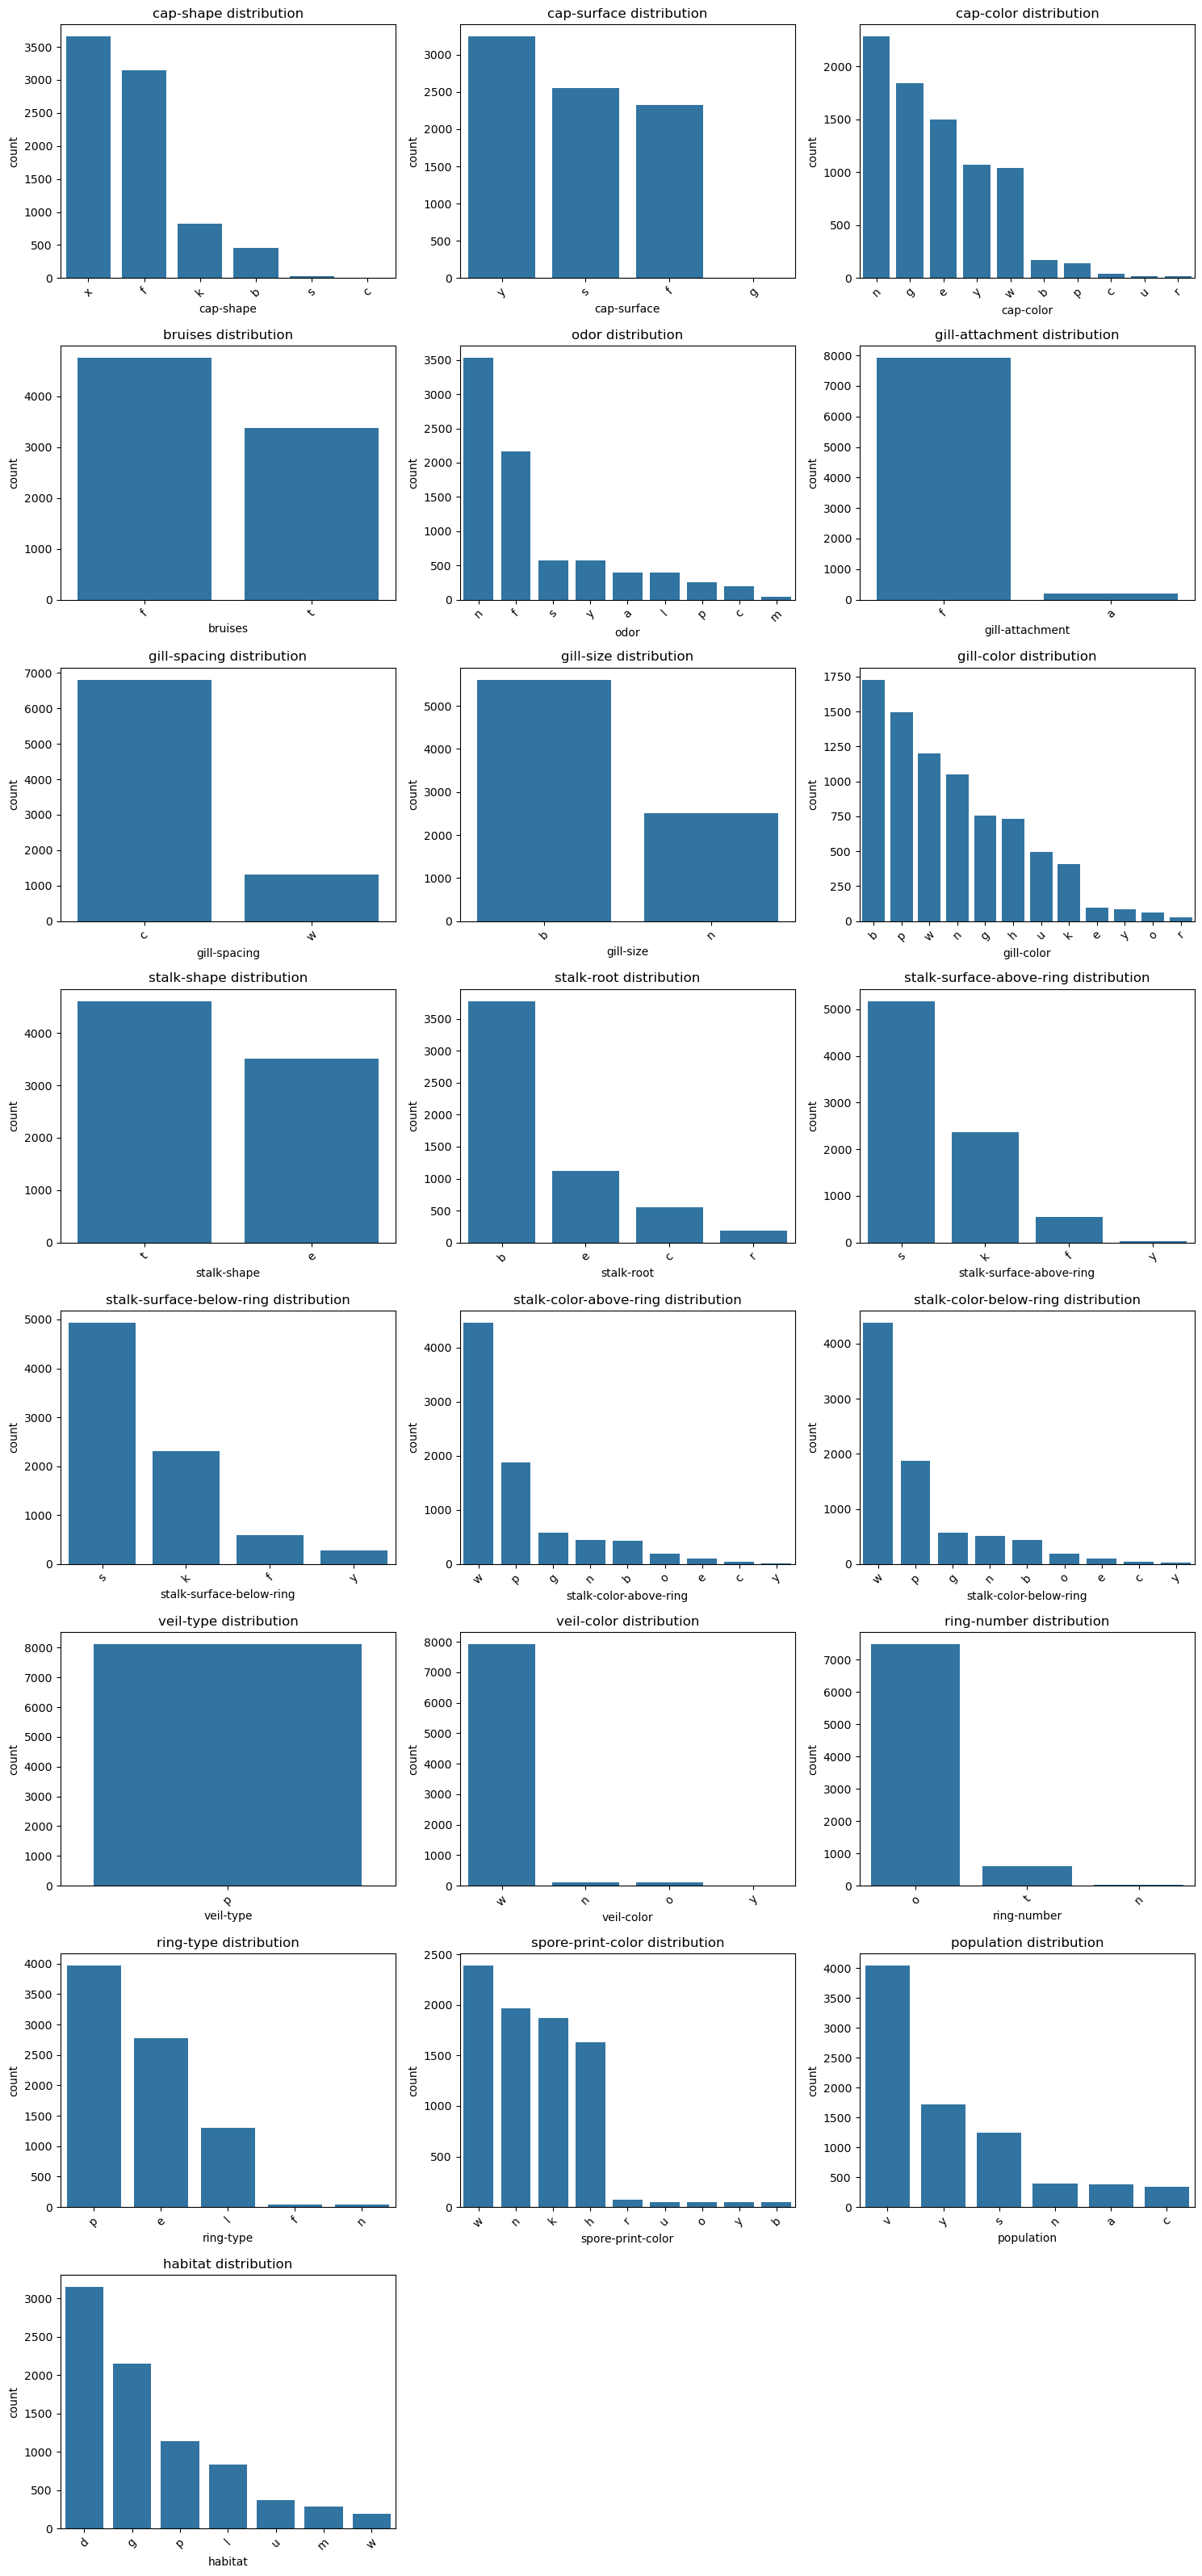

<Figure size 640x480 with 0 Axes>

### Class Distribution

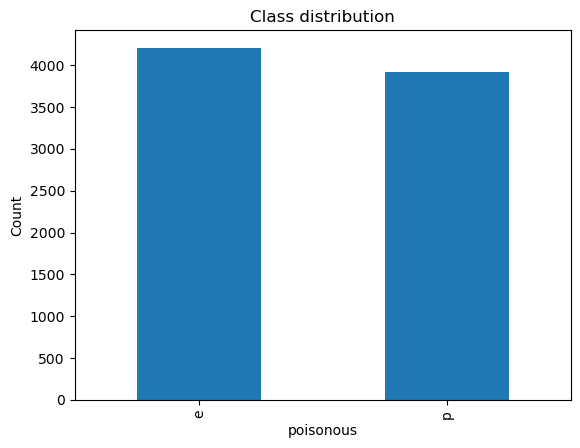

In [4]:
display(Markdown("### Initial Feature Preview"))
display(X.head())
display(Markdown("### Initial Target Preview"))
display(y.head())
display(Markdown("### Feature Missing-Value Check"))
display(X.isnull().sum())
display(Markdown("### Target Missing-Value Check"))
display(y.isnull().sum())
display(Markdown("### Feature Schema Summary"))
X.info()
display(Markdown("### Target Schema Summary"))
y.info()
display(Markdown("### Feature Distributions"))
plot_class_distribution(X)
plt.tight_layout()
plt.show()
display(Markdown("### Class Distribution"))
y.value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

## Training Data Inspection

Create a stratified train-test split and inspect the training data that will drive preprocessing, model selection, and cross-validation.


### Initial Feature Preview

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
5249,f,y,y,f,f,f,c,b,g,e,...,k,p,b,p,w,o,l,h,y,g
5781,x,s,p,t,n,f,c,b,e,e,...,s,e,w,p,w,t,e,w,c,w
7586,b,s,g,f,n,f,w,b,w,e,...,s,w,w,p,w,t,p,w,s,g
6181,f,s,n,f,s,f,c,n,b,t,...,k,p,w,p,w,o,e,w,v,d
7338,k,y,n,f,f,f,c,n,b,t,...,k,p,p,p,w,o,e,w,v,p


### Initial Target Preview

5249    p
5781    e
7586    e
6181    p
7338    p
Name: poisonous, dtype: object

### Feature Missing-Value Check

cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  1968
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

### Target Missing-Value Check

np.int64(0)

### Feature Schema Summary

<class 'pandas.core.frame.DataFrame'>
Index: 6499 entries, 5249 to 2411
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cap-shape                 6499 non-null   object
 1   cap-surface               6499 non-null   object
 2   cap-color                 6499 non-null   object
 3   bruises                   6499 non-null   object
 4   odor                      6499 non-null   object
 5   gill-attachment           6499 non-null   object
 6   gill-spacing              6499 non-null   object
 7   gill-size                 6499 non-null   object
 8   gill-color                6499 non-null   object
 9   stalk-shape               6499 non-null   object
 10  stalk-root                4531 non-null   object
 11  stalk-surface-above-ring  6499 non-null   object
 12  stalk-surface-below-ring  6499 non-null   object
 13  stalk-color-above-ring    6499 non-null   object
 14  stalk-color-below-ring    

### Target Schema Summary

<class 'pandas.core.series.Series'>
Index: 6499 entries, 5249 to 2411
Series name: poisonous
Non-Null Count  Dtype 
--------------  ----- 
6499 non-null   object
dtypes: object(1)
memory usage: 101.5+ KB


### Feature Distributions

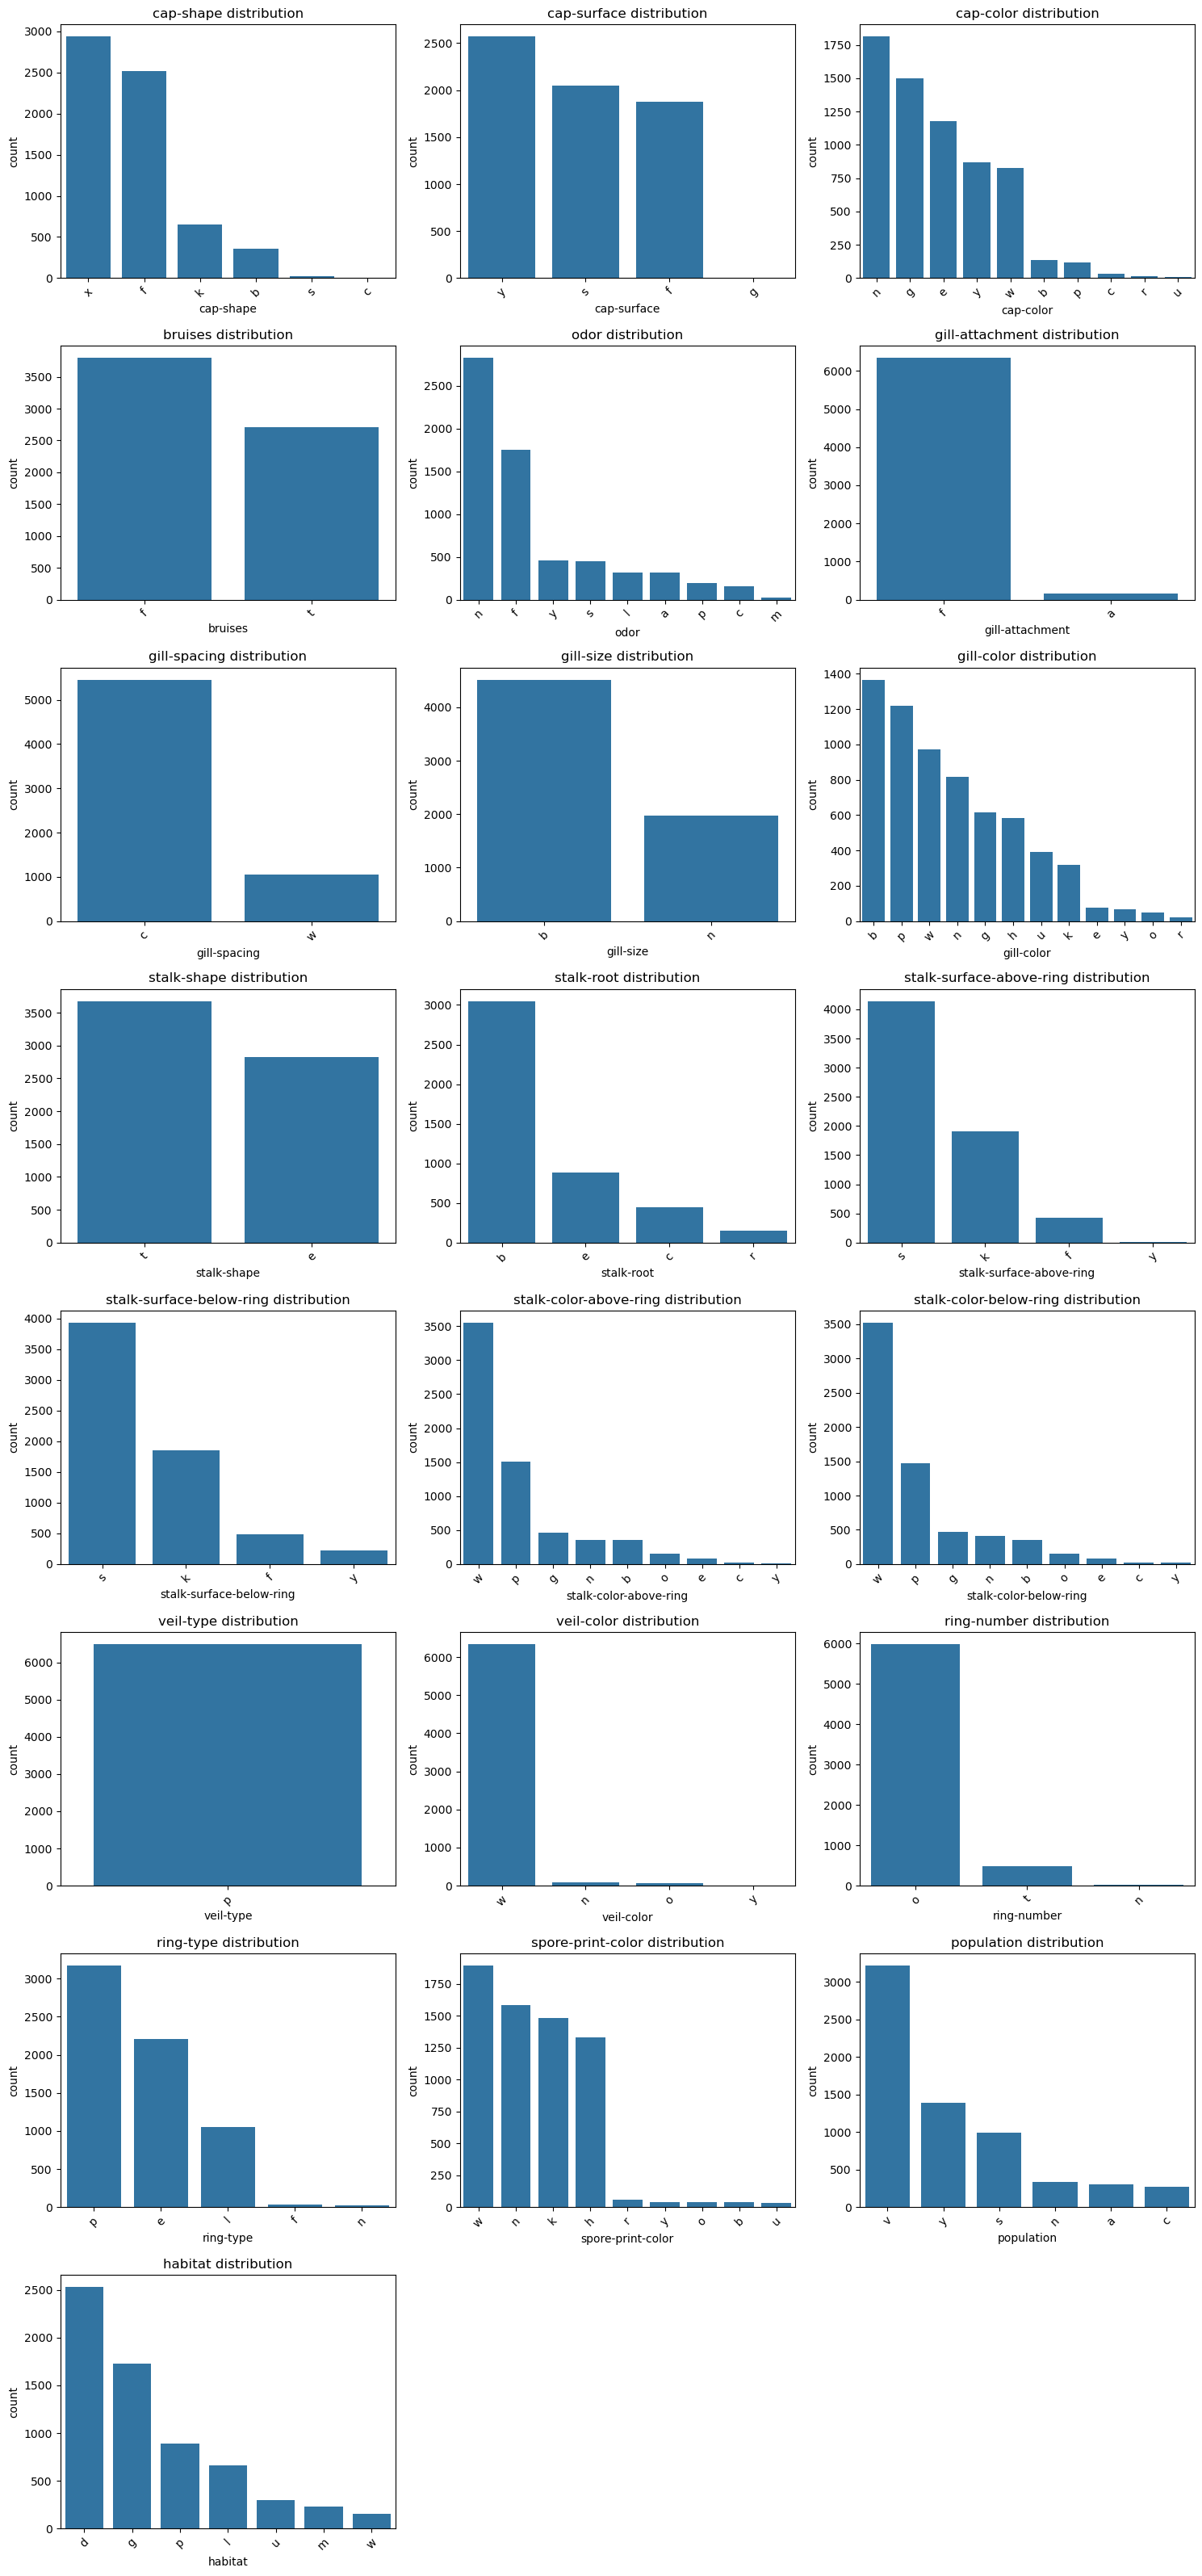

<Figure size 640x480 with 0 Axes>

### Target Class Distribution

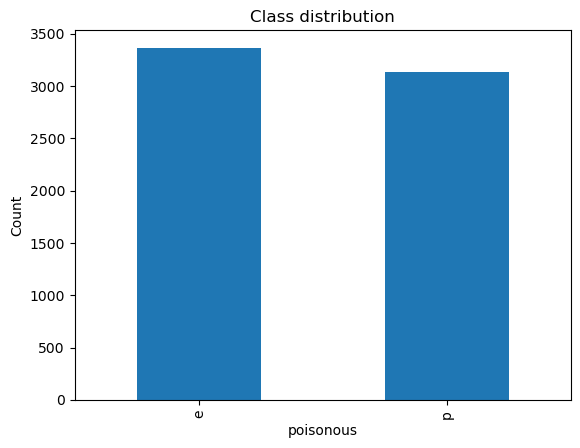

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

display(Markdown("### Initial Feature Preview"))
display(X_train.head())
display(Markdown("### Initial Target Preview"))
display(y_train.head())
display(Markdown("### Feature Missing-Value Check"))
display(X_train.isnull().sum())
display(Markdown("### Target Missing-Value Check"))
display(y_train.isnull().sum())
display(Markdown("### Feature Schema Summary"))
X_train.info()
display(Markdown("### Target Schema Summary"))
y_train.info()
display(Markdown("### Feature Distributions"))
plot_class_distribution(X_train)
plt.tight_layout()
plt.show()
display(Markdown("### Target Class Distribution"))
y_train.value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

### Inspection Notes

The target classes are well balanced and all input features are categorical. The `stalk-root` feature contains missing values, so the preprocessing pipeline treats missing categories explicitly.


## Preprocessing

Impute missing categorical values with a `Missing` category and one-hot encode all features. These transformations are kept inside the model pipeline to avoid data leakage during cross-validation and final evaluation.


In [6]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="Missing"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("cat", cat_pipeline, X_train.columns)
])

## Model Selection

Compare decision-tree, bagging, random-forest, and gradient-boosting classifiers with randomized hyperparameter search using macro F1 as the selection metric.


In [7]:
pipe = Pipeline([
    ("preprocessing", preprocessing),
    ("model", BaggingClassifier())
])

alphas = [0, 0.005, 0.01, 0.02, 0.05, 0.1]
depths = [3, 5, 8, 12, 20]

param_distribution = [
    {
        "model": [
            DecisionTreeClassifier(random_state=42)
        ],
        "model__ccp_alpha": alphas,
        "model__max_depth": depths
    },
    {
        "model": [
            BaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=42),
                random_state=42,
                n_jobs=-1
                )
            ],
        "model__n_estimators": randint(50, 401),
        "model__estimator__ccp_alpha": alphas,
        "model__estimator__max_depth": depths

    },
    {
        "model": [RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )],
        "model__n_estimators": randint(50, 401),
        "model__max_depth": depths

    },
    {
        "model": [GradientBoostingClassifier(
            random_state=42
        )],
        "model__n_estimators": randint(50, 501),
        "model__learning_rate": loguniform(0.01, 0.3),
        "model__max_depth": depths
    }
]

rnd = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distribution,
    scoring="f1_macro",
    cv=5,
    random_state=42,
    n_jobs=-1,
    n_iter=80
)


rnd.fit(X_train, y_train)

best_model = rnd.best_estimator_
display(Markdown("### Cross-Validation Scores"))
display(rnd.cv_results_["mean_test_score"])
display(Markdown("### Best Selected Pipeline"))
best_model

### Cross-Validation Scores

array([1.        , 0.99969189, 0.94612235, 0.99969189, 0.96947493,
       0.94612235, 0.99969189, 0.99969189, 0.94612235, 0.98843819,
       0.98982252, 0.99969189, 1.        , 0.98843819, 1.        ,
       0.98982252, 0.99969189, 0.94612235, 0.99969189, 0.99969189,
       0.96947493, 0.99969189, 0.94612235, 0.99969189, 1.        ,
       0.99969189, 1.        , 0.99969189, 0.99969189, 0.98599061,
       0.98951355, 0.96947493, 0.98889593, 0.98935902, 0.98552771,
       0.98951355, 0.99969189, 0.99969189, 0.98843819, 0.99969189,
       0.9973813 , 0.9973813 , 0.99784257, 0.96947493, 1.        ,
       1.        , 0.98843819, 0.96947493, 0.88680428, 0.88680428,
       0.99969189, 0.98843819, 0.88680428, 0.99969189, 0.99969189,
       0.99969189, 0.94612235, 0.96947493, 0.99969189, 0.99969189,
       0.99969189, 0.94612235, 0.98537397, 0.96947493, 0.99969189,
       0.99676488, 0.88680428, 0.99969189, 0.88680428, 0.99969189,
       0.94612235, 0.99969189, 0.99969189, 0.99969189, 0.99969

### Best Selected Pipeline

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluation

Evaluate the selected pipeline on the held-out test set with classification metrics and the confusion matrix.


Accuracy: 1.0

Classification report:
              precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

Confusion matrix:



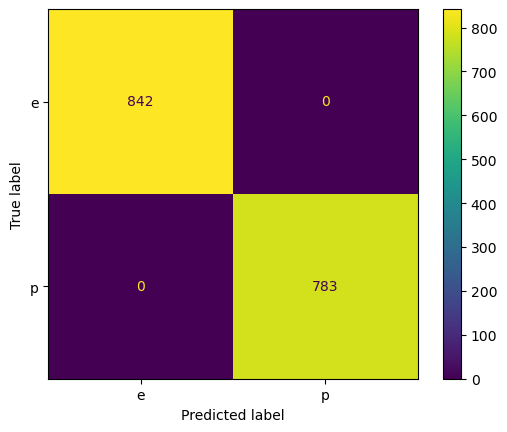

In [10]:
evaluate_classification(best_model, X_test, y_test)

## Final Tree Visualization

Visualize the selected tree structure. If the selected model is an ensemble, show the first fitted tree as a representative member of the final model.


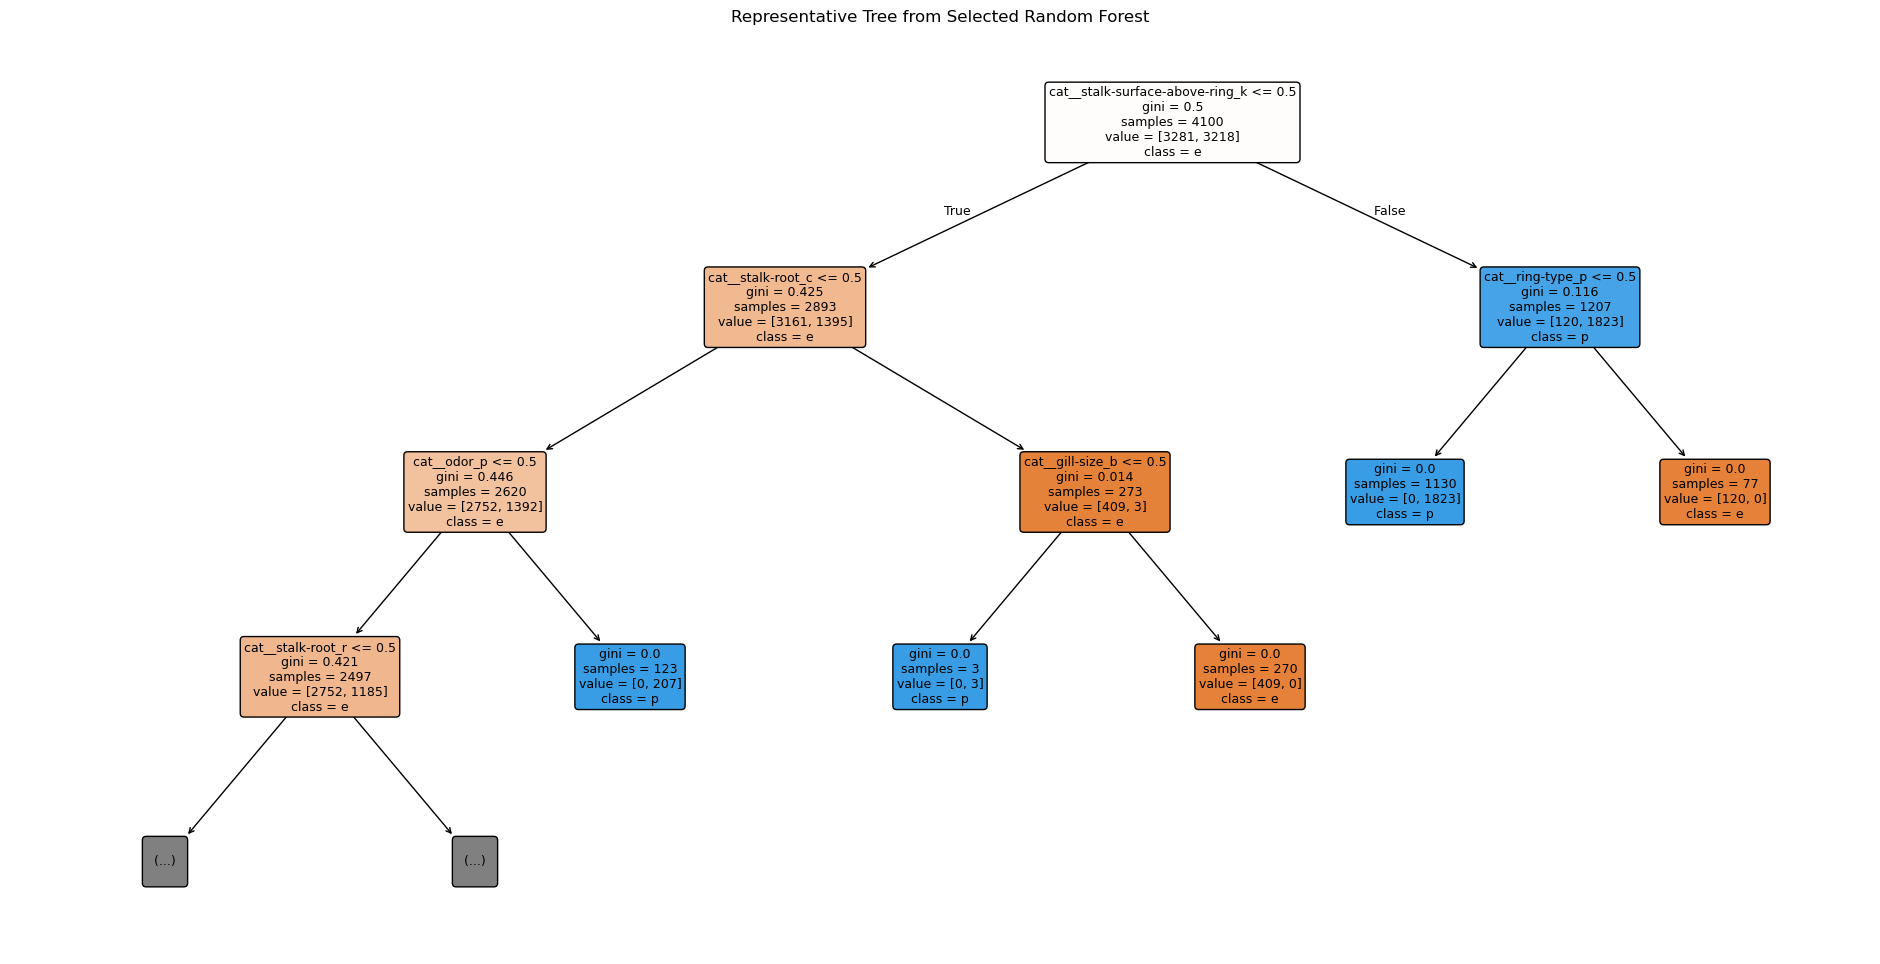

In [9]:
feature_names = best_model.named_steps["preprocessing"].get_feature_names_out()
model = best_model.named_steps["model"]
plot_kwargs = {
    "feature_names": feature_names,
    "filled": True,
    "rounded": True,
    "max_depth": 3,
    "fontsize": 9
}

if isinstance(model, DecisionTreeClassifier):
    tree_to_plot = model
    title = "Selected Decision Tree"
    plot_kwargs["class_names"] = [str(label) for label in best_model.classes_]
elif isinstance(model, BaggingClassifier):
    tree_to_plot = model.estimators_[0]
    title = "Representative Tree from Selected Bagging Model"
    plot_kwargs["class_names"] = [str(label) for label in best_model.classes_]
elif isinstance(model, RandomForestClassifier):
    tree_to_plot = model.estimators_[0]
    title = "Representative Tree from Selected Random Forest"
    plot_kwargs["class_names"] = [str(label) for label in best_model.classes_]
elif isinstance(model, GradientBoostingClassifier):
    tree_to_plot = model.estimators_[0, 0]
    title = "Representative Tree from Selected Gradient Boosting Model"
else:
    raise TypeError(f"Unsupported model type: {type(model).__name__}")

plt.figure(figsize=(24, 12))
plot_tree(tree_to_plot, **plot_kwargs)
plt.title(title)
plt.show()
